# XGBoost for Metadata Analysis

In [ ]:
!pip install fastparquet
#!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.1 MB/s eta 0:00:00


**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
#from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import auc
import seaborn as sns

# Feature Engineering
While most of the feature engineering had been done before the dataset is imported, more problem-specific feature engineering is needed before we can start training and evaluating the model.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/bt4222/df_feature_engineering.parquet'
df_fe = pd.read_parquet(file_path)
df_fe.head()

Mounted at /content/drive


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The counts columns provide a historical record on the counts the speaker got for each label overall, including statements not included in the dataset. However, it does not take into account new labels generated so we manually updated the count based on the label of the specific statement.

In [ ]:
def update_counts(row):
    if row['label'] == 'true':
        row['true_counts'] += 1
    elif row['label'] == 'mostly-true':
        row['mostly_true_counts'] += 1
    elif row['label'] == 'half-true':
        row['half_true_counts'] += 1
    elif row['label'] == 'barely-true':
        row['barely_true_counts'] += 1
    elif row['label'] == 'false':
        row['false_counts'] += 1
    elif row['label'] == 'pants-fire':
        row['pants_on_fire_counts'] += 1
    return row

df_fe = df_fe.apply(update_counts, axis=1)

df_fe.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,3.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290


In [ ]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12786 entries, 0 to 12785
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           12786 non-null  object 
 1   label                        12786 non-null  object 
 2   statement                    12786 non-null  object 
 3   subject                      12786 non-null  object 
 4   speaker                      12786 non-null  object 
 5   speaker_job_title            12786 non-null  object 
 6   state_info                   12786 non-null  object 
 7   party_affiliation            12786 non-null  object 
 8   barely_true_counts           12786 non-null  float64
 9   false_counts                 12786 non-null  float64
 10  half_true_counts             12786 non-null  float64
 11  mostly_true_counts           12786 non-null  float64
 12  pants_on_fire_counts         12786 non-null  float64
 13  context         

Metadata analysis will not be looking at features related to the statements as well as the original columns of embedded features.

In [ ]:
exclude_col=['statement','subject','party_affiliation','speaker_job_title','context','sentiment_polarity','sentiment_subjectivity','statement_embedding','subject_embedding','state_info']
df_embed=df_fe.drop(columns=exclude_col)
df_embed.head()

,id,label,speaker,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,date,true_counts,...,label_barely-true,label_false,label_half-true,label_mostly-true,label_pants-fire,label_true,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding
0,7874.json,half-true,13th district gop slate,0.0,0.0,2.0,0.0,0.0,2013-05-31,0.0,...,0,0,1,0,0,0,31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0..."
1,2287.json,pants-fire,18 percent american public,0.0,0.0,0.0,0.0,2.0,2015-11-22,1.0,...,0,0,0,0,1,0,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ..."
2,13412.json,true,18 percent american public,0.0,0.0,0.0,0.0,1.0,2014-07-18,2.0,...,0,0,0,0,0,1,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ..."
3,2426.json,barely-true,60 plus association,3.0,0.0,0.0,0.0,1.0,2010-09-08,0.0,...,1,0,0,0,0,0,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ..."
4,4832.json,pants-fire,60 plus association,2.0,0.0,0.0,0.0,2.0,2011-11-07,0.0,...,0,0,0,0,1,0,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -..."


For our predictor, we will create a new column called 'reliability'. This column is derived from the aggregation of the counts multiplied by the weights.With the aggregated value, we use it to determine whether the example is reliable (1) or unreliable (0).

In [ ]:
weights = {
    'true_counts': 0.75,
    'mostly_true_counts': 0.5,
    'half_true_counts': 0.25,
    'barely_true_counts': -0.25,
    'false_counts': -0.75,
    'pants_on_fire_counts': -1.0
}


#pants on fire is the most negative label thus -1. But there is no positive equivalent. The closest is true_counts but it is the positive equivalent to false_counts


df_embed['weighted_score'] = (
    df_embed['true_counts'] * weights['true_counts'] +
    df_embed['mostly_true_counts'] * weights['mostly_true_counts'] +
    df_embed['half_true_counts'] * weights['half_true_counts'] +
    df_embed['barely_true_counts'] * weights['barely_true_counts'] +
    df_embed['false_counts'] * weights['false_counts'] +
    df_embed['pants_on_fire_counts'] * weights['pants_on_fire_counts']
)

label_boost = {
    'true': 0.75,
    'mostly-true': 0.5,
    'half-true': 0.25,
    'barely-true': -0.25,
    'false': -0.75,
    'pants-fire': -1.0
}

df_embed['weighted_score'] += df_embed['label'].map(label_boost).fillna(0)

df_embed['speaker_reliable'] = (df_embed['weighted_score'] > 0).astype(int)


In [ ]:
df_embed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12786 entries, 0 to 12785
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           12786 non-null  object 
 1   label                        12786 non-null  object 
 2   speaker                      12786 non-null  object 
 3   barely_true_counts           12786 non-null  float64
 4   false_counts                 12786 non-null  float64
 5   half_true_counts             12786 non-null  float64
 6   mostly_true_counts           12786 non-null  float64
 7   pants_on_fire_counts         12786 non-null  float64
 8   date                         12786 non-null  object 
 9   true_counts                  12786 non-null  float64
 10  total_counts                 12786 non-null  float64
 11  label_barely-true            12786 non-null  int64  
 12  label_false                  12786 non-null  int64  
 13  label_half-true 

In [ ]:
#speaker encoding
le = LabelEncoder()
df_embed['speaker_encoded'] = le.fit_transform(df_embed['speaker'])
df_embed=df_embed.drop(columns=['speaker'])

In [ ]:
df_embed.head()
#exclude trueish and falseish, predict speaker reliability

,id,label,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,date,true_counts,total_counts,...,label_mostly-true,label_pants-fire,label_true,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,weighted_score,speaker_reliable,speaker_encoded
0,7874.json,half-true,0.0,0.0,2.0,0.0,0.0,2013-05-31,0.0,1.0,...,0,0,0,31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.75,1,0
1,2287.json,pants-fire,0.0,0.0,0.0,0.0,2.0,2015-11-22,1.0,2.0,...,0,1,0,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",-2.25,0,1
2,13412.json,true,0.0,0.0,0.0,0.0,1.0,2014-07-18,2.0,4.0,...,0,0,1,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",1.25,1,1
3,2426.json,barely-true,3.0,0.0,0.0,0.0,1.0,2010-09-08,0.0,3.0,...,0,0,0,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",-2.00,0,2
4,4832.json,pants-fire,2.0,0.0,0.0,0.0,2.0,2011-11-07,0.0,6.0,...,0,1,0,45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",-3.50,0,2


In [ ]:
df_embed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12786 entries, 0 to 12785
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           12786 non-null  object 
 1   label                        12786 non-null  object 
 2   barely_true_counts           12786 non-null  float64
 3   false_counts                 12786 non-null  float64
 4   half_true_counts             12786 non-null  float64
 5   mostly_true_counts           12786 non-null  float64
 6   pants_on_fire_counts         12786 non-null  float64
 7   date                         12786 non-null  object 
 8   true_counts                  12786 non-null  float64
 9   total_counts                 12786 non-null  float64
 10  label_barely-true            12786 non-null  int64  
 11  label_false                  12786 non-null  int64  
 12  label_half-true              12786 non-null  int64  
 13  label_mostly-tru

In [ ]:
df_embed_temp=df_embed.head(100)

As the values in the speaker job title embedding and context embedding are in array (something trees cannot handle!), we have to flatten the array, but this would result in hundreds of new columns. There are 2 ways to solve this issue:
- compressing it using PCA
- obtaining the statistical values of the arrays.

We went with the second version method as the first method would still generate roughly 30 new columns which would affect the performance drastically.

In [ ]:
df_embed['speaker_emb_mean'] = df_embed['speaker_job_title_embedding'].apply(np.mean)
df_embed['speaker_emb_std'] = df_embed['speaker_job_title_embedding'].apply(np.std)
df_embed['context_embedding_mean'] = df_embed['context_embedding'].apply(np.mean)
df_embed['context_embedding_std']=df_embed['context_embedding'].apply(np.std)
col=['speaker_job_title_embedding','context_embedding']
df_embed.drop(columns=col, inplace=True)

In [ ]:
df_embed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12786 entries, 0 to 12785
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         12786 non-null  object 
 1   label                      12786 non-null  object 
 2   barely_true_counts         12786 non-null  float64
 3   false_counts               12786 non-null  float64
 4   half_true_counts           12786 non-null  float64
 5   mostly_true_counts         12786 non-null  float64
 6   pants_on_fire_counts       12786 non-null  float64
 7   date                       12786 non-null  object 
 8   true_counts                12786 non-null  float64
 9   total_counts               12786 non-null  float64
 10  label_barely-true          12786 non-null  int64  
 11  label_false                12786 non-null  int64  
 12  label_half-true            12786 non-null  int64  
 13  label_mostly-true          12786 non-null  int

# **Split train test**

We will split the dataset into 80% training and 20% testing.

In [ ]:
#remove the trueish and falseish col
#df_embed=df_embed.drop(columns=['trueish','falseish'])
leaky_cols = [
    'barely_true_counts', 'false_counts', 'half_true_counts',
    'mostly_true_counts', 'pants_on_fire_counts', 'true_counts', 'total_counts', 'date','label', 'id'
]
leaky_label_cols = [col for col in df_embed.columns if col.startswith('label_')]
df_embed = df_embed.drop(columns=leaky_label_cols)
df_embed=df_embed.drop(columns=leaky_cols)
#split 0.3
target_col=['speaker_reliable']
feature_col=list(df_embed)
feature_col.remove('speaker_reliable')
feature_col.remove('weighted_score')
print(feature_col)


['state_info_encoded', 'party_affiliation_encoded', 'speaker_encoded', 'speaker_emb_mean', 'speaker_emb_std', 'context_embedding_mean', 'context_embedding_std']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_embed[feature_col], df_embed[target_col], test_size=0.2, random_state=42)

In [ ]:
X_train.head()

,state_info_encoded,party_affiliation_encoded,speaker_encoded,speaker_emb_mean,speaker_emb_std,context_embedding_mean,context_embedding_std
8909,40,6,2266,0.000089,0.051031,-0.000505,0.051029
4975,51,6,1226,0.001884,0.050996,-0.000395,0.051030
3717,33,8,864,0.000507,0.051029,-0.000245,0.051030
6504,2,8,1595,-0.000435,0.051029,-0.001132,0.051018
4026,45,7,920,0.000697,0.051026,-0.000101,0.051031


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2558 entries, 7864 to 7808
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   state_info_encoded         2558 non-null   int64  
 1   party_affiliation_encoded  2558 non-null   int64  
 2   speaker_encoded            2558 non-null   int64  
 3   speaker_emb_mean           2558 non-null   float64
 4   speaker_emb_std            2558 non-null   float64
 5   context_embedding_mean     2558 non-null   float64
 6   context_embedding_std      2558 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 159.9 KB


# Base Model: Decision Tree
XGBoost is made up trees, thus we will use its basic form, Decision Tree, as our "minimum" performance



In [ ]:
#BASELINE DECISION TREE WITH NO TUNING
model = DecisionTreeClassifier()
model = model.fit(X_train,y_train)
y_pred = model.predict(X_test)
probs = model.predict_proba(X_test)


In [ ]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7529319781078968


In [ ]:
reliability_scores = probs[:, 1]
roc_auc_val = roc_auc_score(y_test, reliability_scores)
print("ROC AUC Score:", roc_auc_val)

ROC AUC Score: 0.7595791114575214


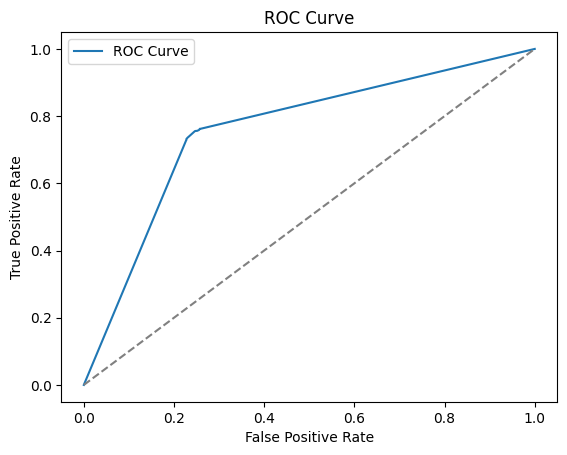

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, reliability_scores)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The odd shape of the decision tree model tells us that the model is only producing a few distinct probability values, which is expected for unpruned decision trees as a tree tends to predict class probabilities based on the proportion of samples in the leaf node.

# Tested Model: XGBoost
We generate a baseline XGBoost model, using default hyperparameters

In [ ]:
#BASELINE XGBOOST WITH NO TUNING
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Fit the model
xgb_model=xgb_model.fit(X_train, y_train)
y_pred_test = xgb_model.predict(X_test)
probs = xgb_model.predict_proba(X_test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:46:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8991982792334767

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90      5199
           1       0.89      0.90      0.90      5029

    accuracy                           0.90     10228
   macro avg       0.90      0.90      0.90     10228
weighted avg       0.90      0.90      0.90     10228

ROC AUC Score: 0.9688473902720252
Precision (macro): 0.8991663454714534
Recall (macro): 0.8992663287688094
F1-score (macro): 0.8991864056005611
Confusion Matrix:
 [[4654  545]
 [ 486 4543]]


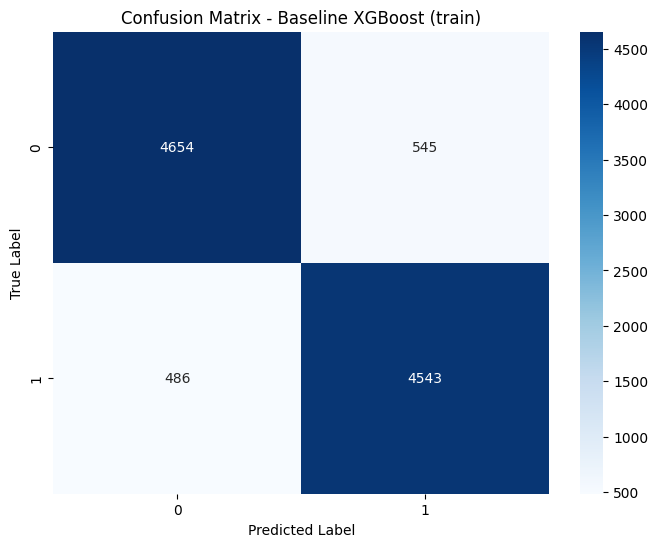

In [ ]:
#TRAIN SET
y_pred_train = xgb_model.predict(X_train)
probs_train = xgb_model.predict_proba(X_train)
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))
reliability_scores = probs_train[:, 1]
roc_auc_val = roc_auc_score(y_train, reliability_scores)
print("ROC AUC Score:", roc_auc_val)

# Evaluation Metrics
label_order = [0, 1]
print("Precision (macro):", precision_score(y_train, y_pred_train, average='macro'))
print("Recall (macro):", recall_score(y_train, y_pred_train, average='macro'))
print("F1-score (macro):", f1_score(y_train, y_pred_train, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))

# Logistic Regression Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Baseline XGBoost (train)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The baseline training set has an ROC AUC score of 0.968847 tells us that the model is able to predict reliable (1) to an input that's actually labelled reliable about 96.9% of the time.

With an accuracy score of 0.89920, it tells us that the model is able to predict the correct label 89.9% of the time.

In [ ]:
#TEST SET
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7529319781078968

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.77      0.76      1275
           1       0.76      0.74      0.75      1283

    accuracy                           0.75      2558
   macro avg       0.75      0.75      0.75      2558
weighted avg       0.75      0.75      0.75      2558



In [ ]:
reliability_scores = probs[:, 1]
roc_auc_val = roc_auc_score(y_test, reliability_scores)
print("ROC AUC Score:", roc_auc_val)

ROC AUC Score: 0.8642428132593645


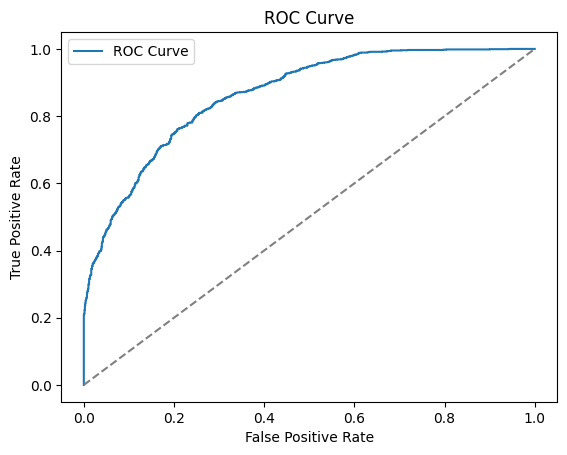

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, reliability_scores)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Precision (macro): 0.7532019454269678
Recall (macro): 0.7529809117723474
F1-score (macro): 0.7528883214963511
Confusion Matrix:
 [[980 295]
 [337 946]]


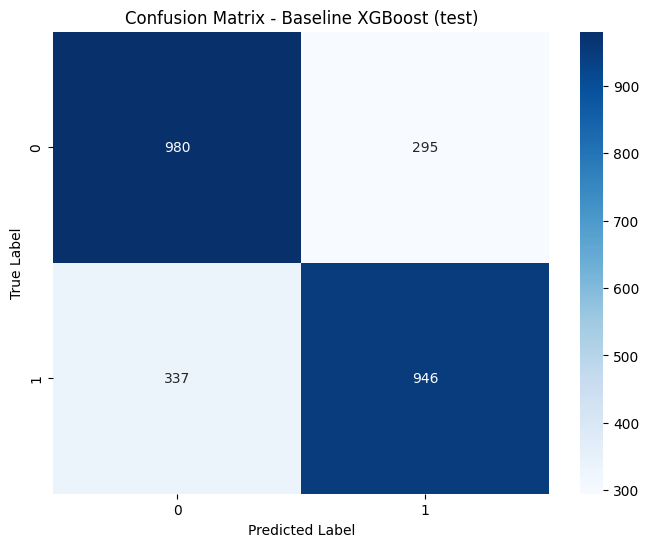

In [ ]:
# Evaluation Metrics
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Baseline XGBoost (test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The baseline test set has an ROC AUC score of 0.86424 tells us that the model is able to predict reliable (1) to an input that's actually labelled reliable about 86.4% of the time.

With an accuracy score of 0.75332, it tells us that the model is able to predict the correct label 75.3% of the time.

Unsurprisingly, the baseline XGBoost model performed a lot better than the baseline Decision Tree model. This is expected since not only is the Decision Tree a simple model, but XGBoost is a type of ensemble model that makes use of Gradient Boosting.

In [ ]:
# Print column names
print(X_train.columns.tolist())

['state_info_encoded', 'party_affiliation_encoded', 'speaker_encoded', 'speaker_emb_mean', 'speaker_emb_std', 'context_embedding_mean', 'context_embedding_std']


# Tuning of XGBoost


In [ ]:
# Define the parameter grid for randomized search
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_lambda': [1, 5, 10],
    'reg_alpha': [0, 1, 5]
}

#n_estimator: number of trees in the model (more trees-> more specific. less trees -> more general)
#max_depth: maximum depth of each trees
#learning rate: shrinks the contribution of each tree
#subsample: fraction of the training data randomly sampled for each boosting round
#colsample_bytree: fraction of features used to grow each tree
#gamma: minimum loss reduction required to make a further partition on a leaf
#reg_lambda: L2 regularization
#reg_alpha: L1 regularization

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations to try
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train)


best_model = random_search.best_estimator_ #the best model here
print("Best ROC AUC Score: ", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))
print("Best Parameters: ", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:54:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best ROC AUC Score:  0.8638885577613743
Best Parameters:  {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}


From the hyperparameter tuning, we get the best performing model using the hyperparmeters:
- subsample: 0.8
- reg_lambda: 5
- reg_alpha: 1
- n_estimator: 100
- max_depth: 10
- learning_rate: 0.05
- gamma: 0
- colsample_bytree: 0.6


ROC AUC Score: 0.9392883460962005
Accuracy: 0.8568635119280407

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86      5199
           1       0.85      0.86      0.86      5029

    accuracy                           0.86     10228
   macro avg       0.86      0.86      0.86     10228
weighted avg       0.86      0.86      0.86     10228

Precision (macro): 0.8568295819249627
Recall (macro): 0.8569182373700128
F1-score (macro): 0.8568463464049139
Confusion Matrix:
 [[4438  761]
 [ 703 4326]]


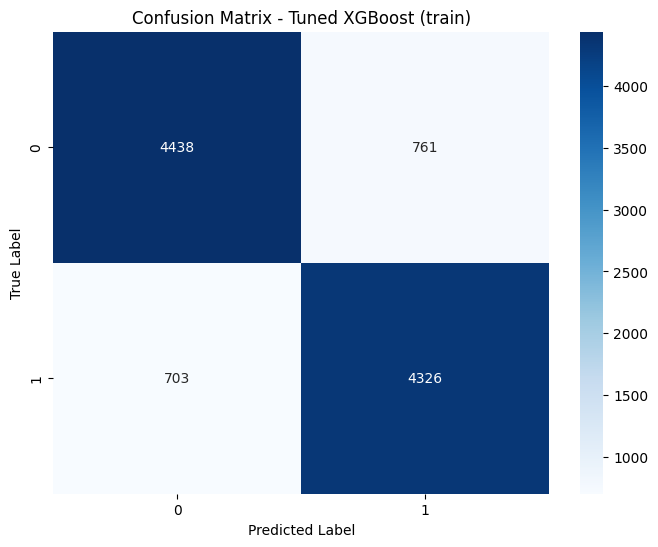

In [ ]:
#TRAIN SET
y_probs_tune_train = best_model.predict_proba(X_train)[:,1]
fpr_tune, tpr_tune, _ = roc_curve(y_train, y_probs_tune_train)
roc_auc_tune = auc(fpr_tune, tpr_tune)
print("ROC AUC Score:", roc_auc_tune)
y_probs_tune_train = best_model.predict(X_train)
print("Accuracy:", accuracy_score(y_train, y_probs_tune_train))
print("\nClassification Report:\n", classification_report(y_train, y_probs_tune_train))

# Evaluation Metrics
print("Precision (macro):", precision_score(y_train, y_probs_tune_train, average='macro'))
print("Recall (macro):", recall_score(y_train, y_probs_tune_train, average='macro'))
print("F1-score (macro):", f1_score(y_train, y_probs_tune_train, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_probs_tune_train))

# Confusion Matrix
cm = confusion_matrix(y_train, y_probs_tune_train)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Tuned XGBoost (train)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The tuned training set has an ROC AUC score of 0.939 tells us that the model is able to predict reliable (1) to an input that's actually labelled reliable about 93.9% of the time.

With an accuracy score of 0.85686, it tells us that the model is able to predict the correct label 85.7% of the time.

ROC AUC Score: 0.8638885577613743
Accuracy: 0.7650508209538702

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77      1275
           1       0.77      0.76      0.76      1283

    accuracy                           0.77      2558
   macro avg       0.77      0.77      0.77      2558
weighted avg       0.77      0.77      0.77      2558



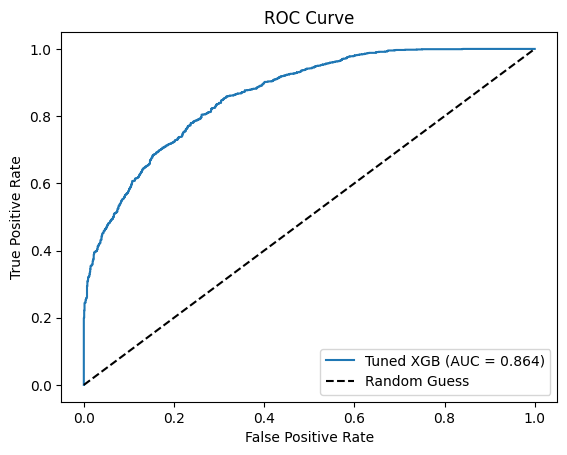

In [ ]:
#TEST SET
y_probs_tune = best_model.predict_proba(X_test)[:,1]
fpr_tune, tpr_tune, _ = roc_curve(y_test, y_probs_tune)
roc_auc_tune = auc(fpr_tune, tpr_tune)
print("ROC AUC Score:", roc_auc_tune)
y_probs_tune_test = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_probs_tune_test))
print("\nClassification Report:\n", classification_report(y_test, y_probs_tune_test))

plt.figure()
plt.plot(fpr_tune, tpr_tune, label='Tuned XGB (AUC = {:.3f})'.format(roc_auc_tune))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Precision (macro): 0.7651646902854012
Recall (macro): 0.765081533782648
F1-score (macro): 0.7650378579988424
Confusion Matrix:
 [[988 287]
 [314 969]]


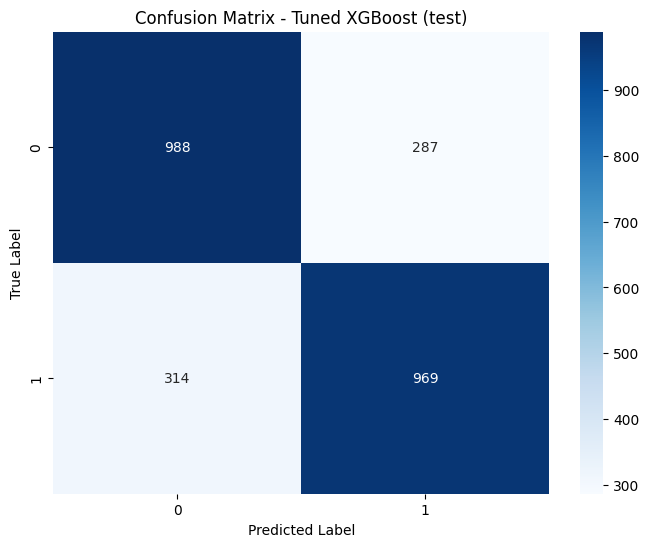

In [ ]:
# Evaluation Metrics
print("Precision (macro):", precision_score(y_test, y_probs_tune_test, average='macro'))
print("Recall (macro):", recall_score(y_test, y_probs_tune_test, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_probs_tune_test, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_probs_tune_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_probs_tune_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Tuned XGBoost (test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The tuned test set has an ROC AUC score of 0.86389 tells us that the model is able to predict that an input is reliable (1) when it is actually labelled reliable about 86.4% of the time. This is also verified by the best ROC AUC score from our hyperparameter tuning earlier

With an accuracy score of 0.76505, it tells us that the model is able to predict the correct label 76.5% of the time.

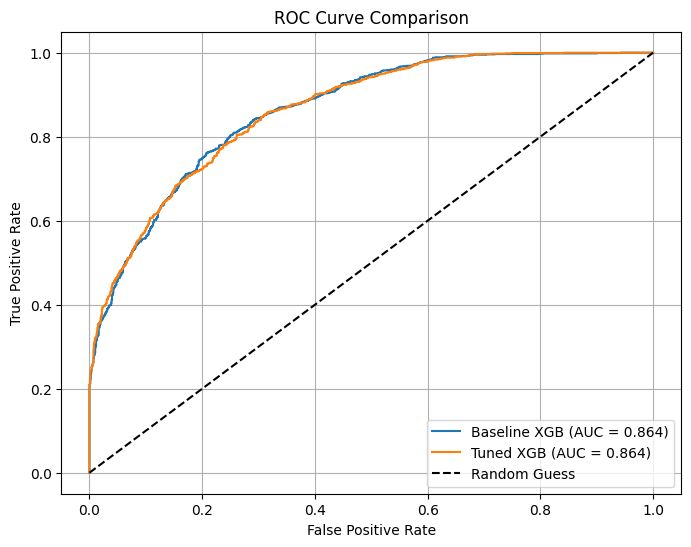

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Baseline XGB (AUC = {:.3f})'.format(roc_auc_val))
plt.plot(fpr_tune, tpr_tune, label='Tuned XGB (AUC = {:.3f})'.format(roc_auc_tune))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#The AUC represents how well the model separates the classes (positives vs. negatives), regardless of the decision threshold.

We can compare the performance of the baseline XGBoost tree and the tuned XGBoost tree. Supported by the scores from the respective models, tuning the model did not significantly improve the performance of the model.

# For Ensemble Model - Use final model for predictions on entire dataset and save as csv

With ensemble learning, the output of the first model is used as the input for the next model. Thus, we used the final tuned model to generate predictions on the whole dataset and save it as CSV.

In [ ]:
# Ensure preprocessing consistency
df_final = df_embed.copy()
df_final

In [ ]:
# Ensure preprocessing consistency
df_final = df_embed.copy()

# Use same feature columns as during training
df_final_processed = df_final[feature_col]

# Predict probabilities using trained XGBoost model
df_final['reliability_probability'] = best_model.predict_proba(df_final_processed)[:, 1]

# Map predictions back to 'id' using index
results_df = df_fe[['id']].copy()
results_df['reliability_probability'] = df_final['reliability_probability']

# Save to CSV
csv_file_path = '/content/drive/My Drive/BT4222/data/xgboost_predictions.csv'
results_df.to_csv(csv_file_path, index=False)

print(f"Predictions saved to Google Drive at {csv_file_path}.")
results_df.head()